# Per-cell SBS signature exposures (scNanoSeq)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Patch

# ---- Global paths -----------------------------------------------------------
SUPP_DIR   = "../supplemental_tables_v2"
SUPTABLE5  = f"{SUPP_DIR}/SupTable12_scNanoseq_allResults.xlsx"   # per-cell signature exposures
SUPTABLE7  = f"{SUPP_DIR}/SupTable15_PerCell_HRDScout_predictions.xlsx"  # lineage + burden
OUTDIR     = "../output/SuppFig_scNanoSeq_perCell_signature_exposures"
os.makedirs(OUTDIR, exist_ok=True)

# ---- Constants --------------------------------------------------------------
SIGNATURES = ["SBS1","SBS2","SBS3","SBS5","SBS8","SBS13","SBS17b","SBS18","SBS30",
              "denovo_(SBS169)","denovo_(SBS127)"]
SIGNATURE_PALETTE = ["k","#F4AC45","#92BFB1","#A61C3C","#748E54","#C297B8",
                     "#FDCFF3","#F28482","#754668","#009FB7","#aec7e8"]
SIG_COLOR = dict(zip(SIGNATURES, SIGNATURE_PALETTE))
LINEAGE_STYLE = {"in_tumor_lineage":("#8f9cc2","Tumor"),
                 "tumor_adjacent_lineage":("#e8b4b4","Tumor-adjacent"),
                 "normal":("#e6e7e8","Normal")}
LINEAGE_ORDER = {"normal":0, "tumor_adjacent_lineage":1, "in_tumor_lineage":2}


def set_mpl_style():
    mpl.rcParams.update({
        "pdf.fonttype":42, "ps.fonttype":42,
        "font.family":"sans-serif", "font.size":8,
        "text.color":"black", "axes.labelcolor":"black",
        "axes.spines.top":False, "axes.spines.right":False,
        "axes.linewidth":0.25, "axes.edgecolor":"black",
        "xtick.color":"black", "ytick.color":"black",
        "xtick.direction":"out", "ytick.direction":"out",
        "xtick.major.width":0.25, "ytick.major.width":0.25,
        "xtick.major.size":3, "ytick.major.size":3,
        "xtick.labelsize":7, "ytick.labelsize":7,
        "legend.fontsize":7, "legend.title_fontsize":7, "figure.dpi":150,
    })

set_mpl_style()


In [2]:
# Signature exposures (already normalized per cell) from Supplementary Table 5
exposures = pd.read_excel(SUPTABLE5, sheet_name="S3.scNanoseq")
exposures = exposures.set_index("cell_name")[SIGNATURES].dropna(how="all")

# Lineage + mutation burden from Supplementary Table 7
predictions = pd.read_excel(SUPTABLE7, sheet_name="Per-cell Predictions").set_index("cell_id")

# Keep cells present in both tables
cells = exposures.index.intersection(predictions.index)
exposures   = exposures.loc[cells]
lineage     = predictions.loc[cells, "cell_lineage"]
burden      = predictions.loc[cells, "mutation_count"]
sample_of   = pd.Series(cells.str[:4], index=cells)


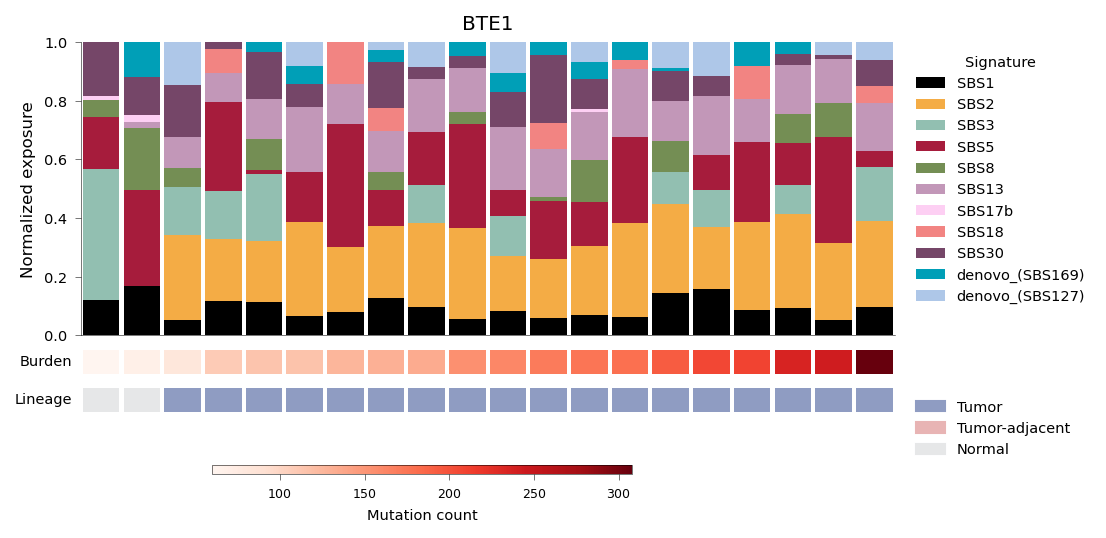

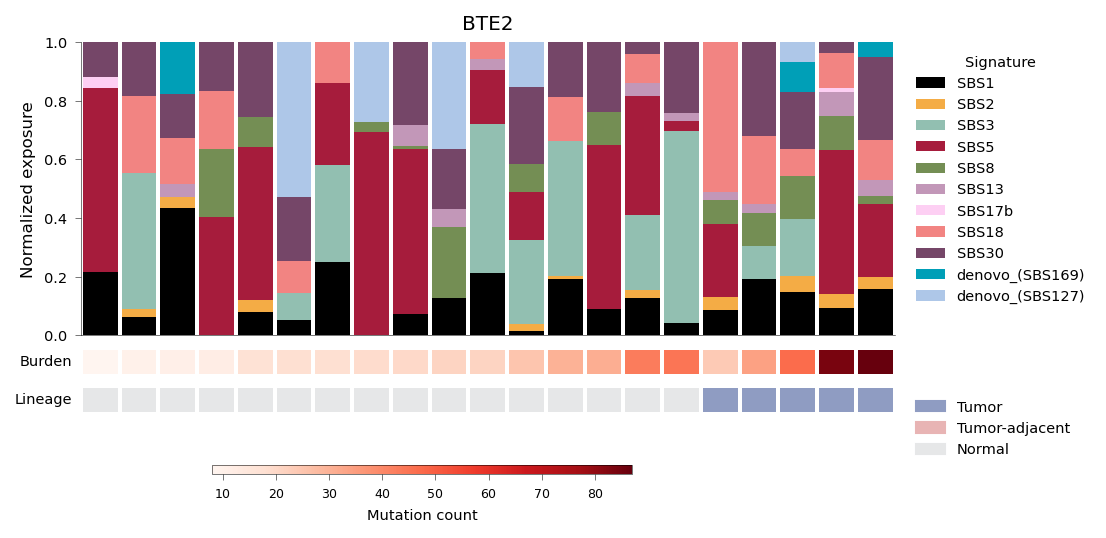

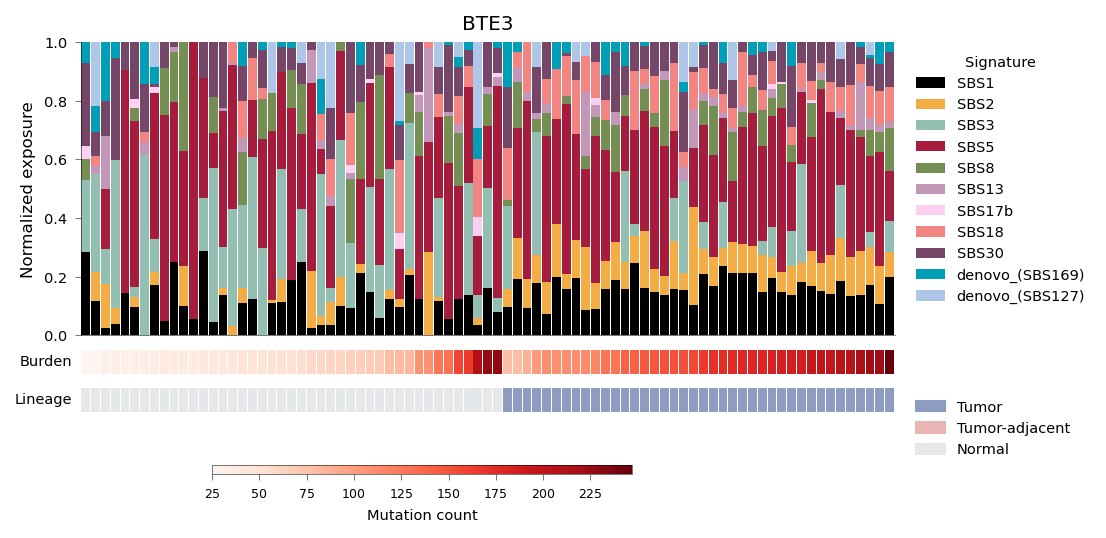

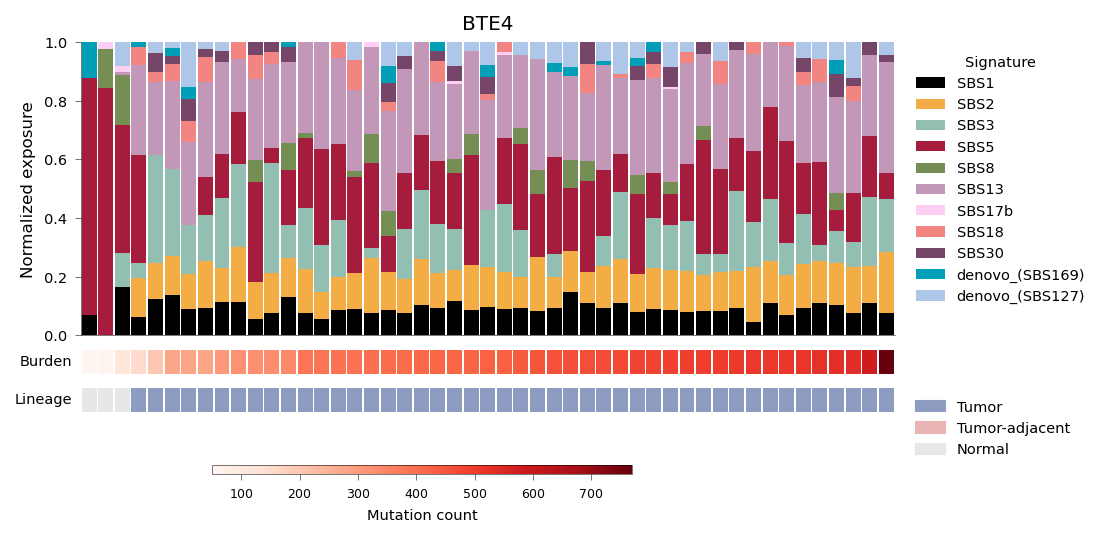

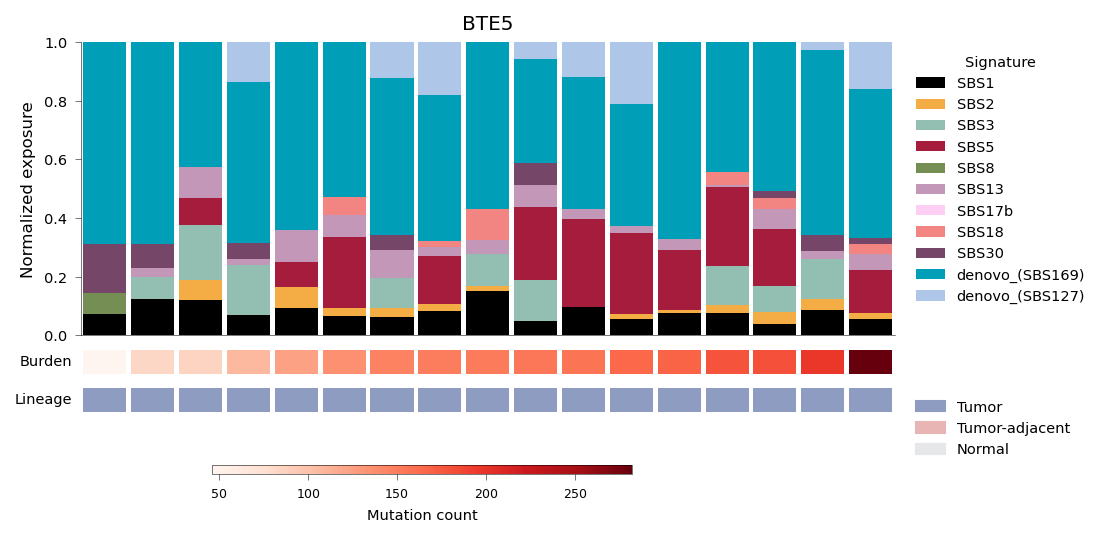

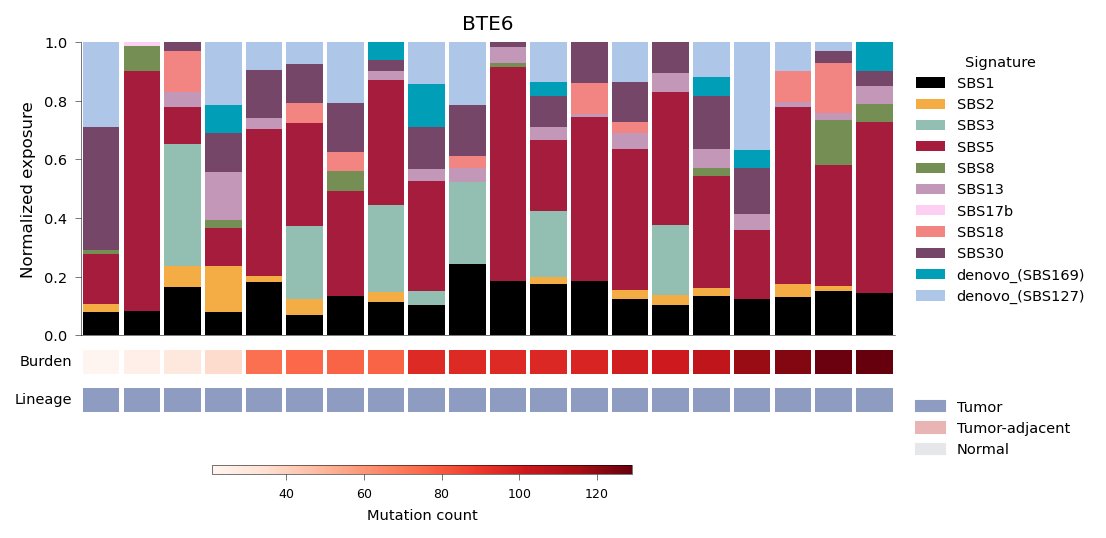

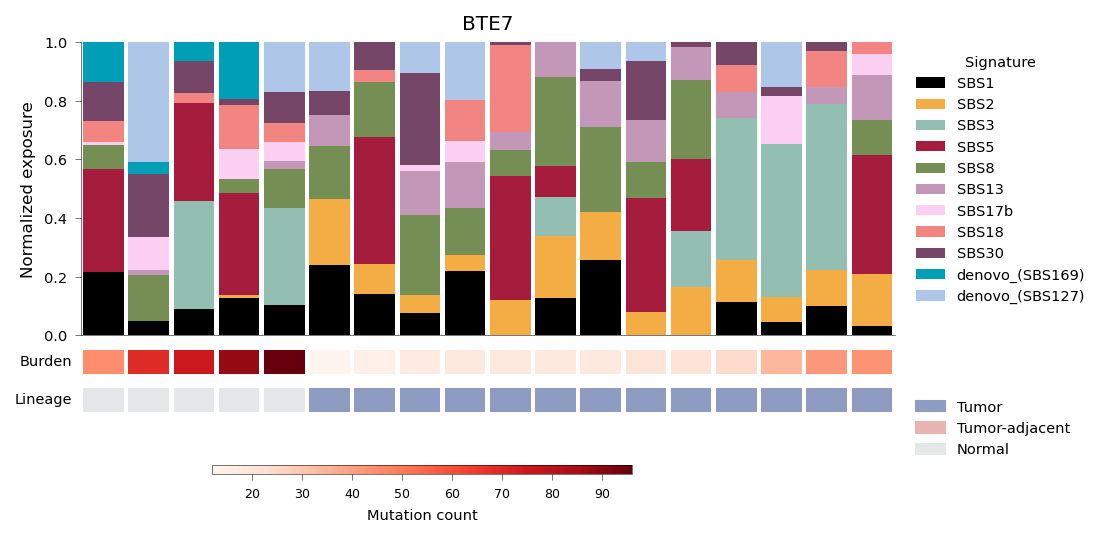

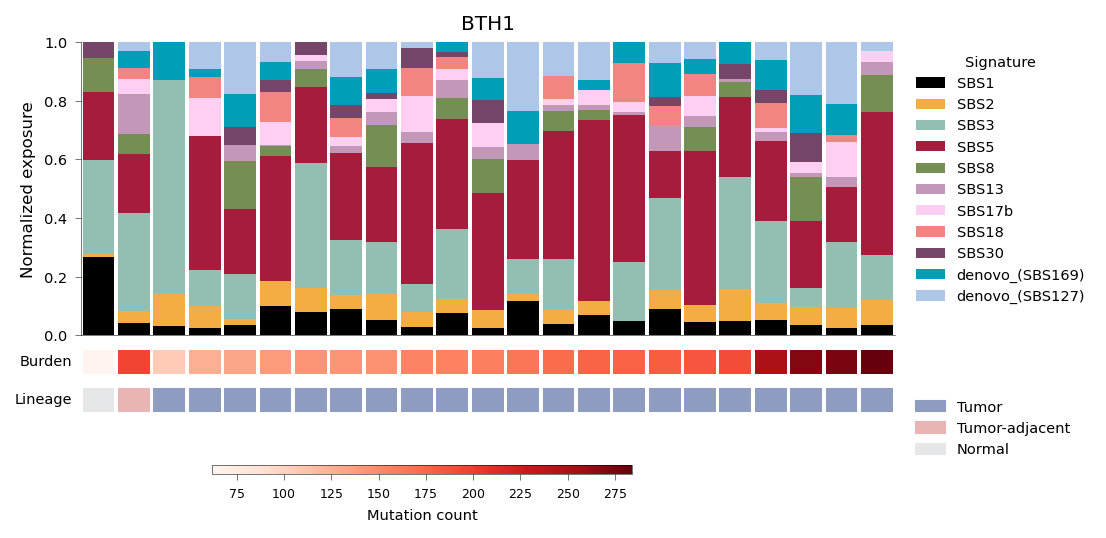

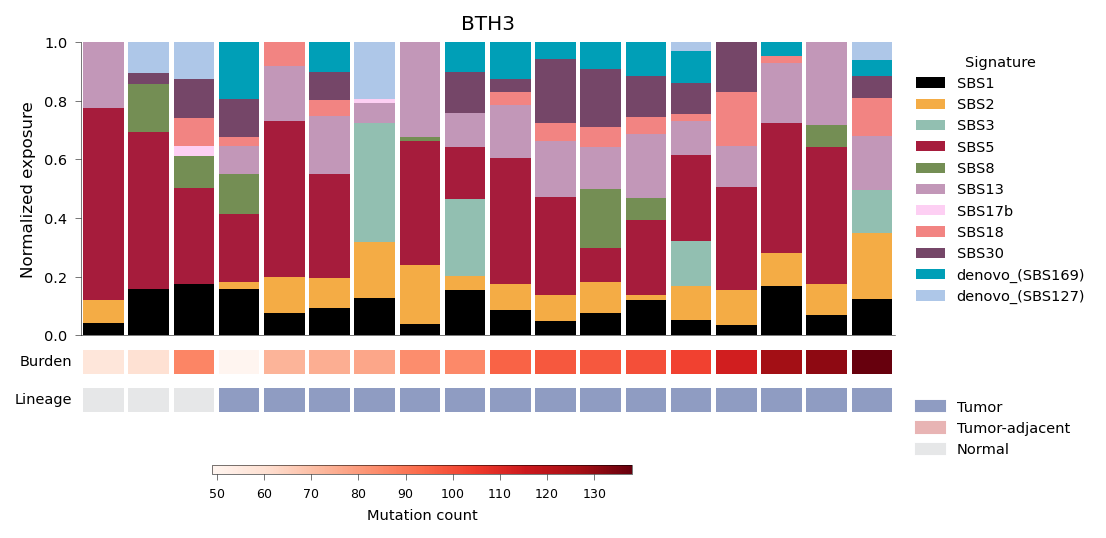

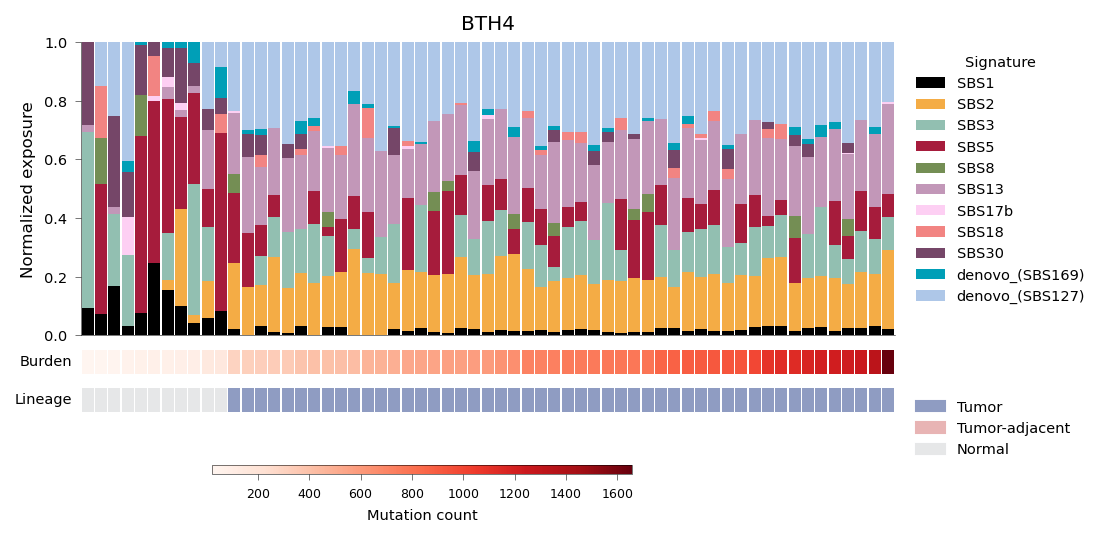

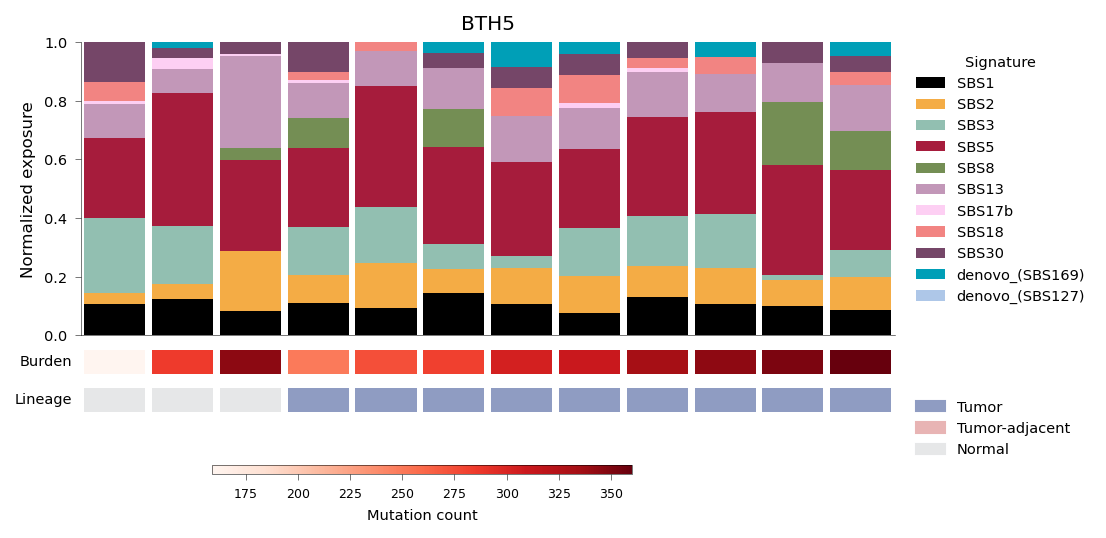

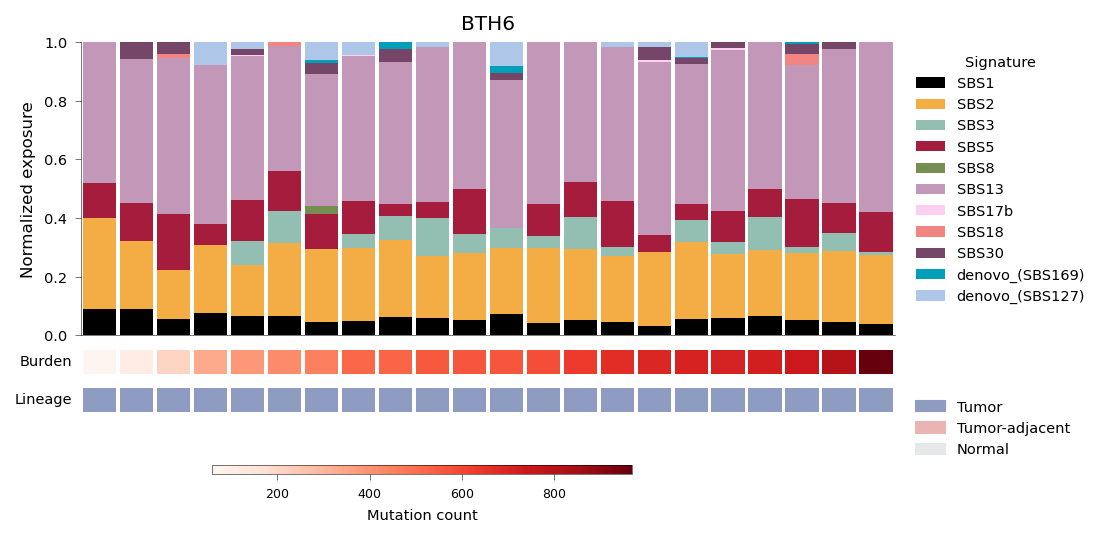

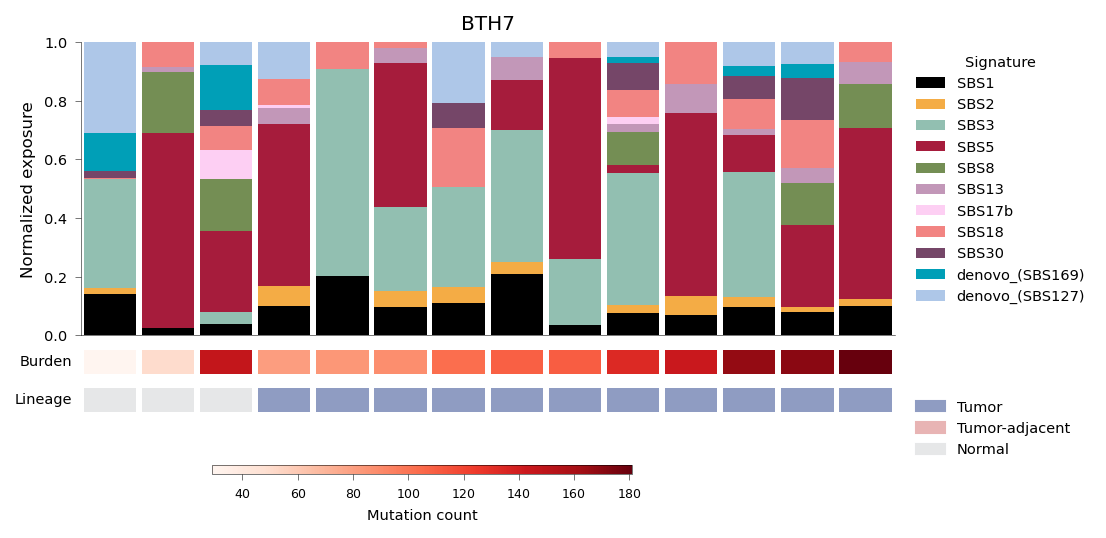

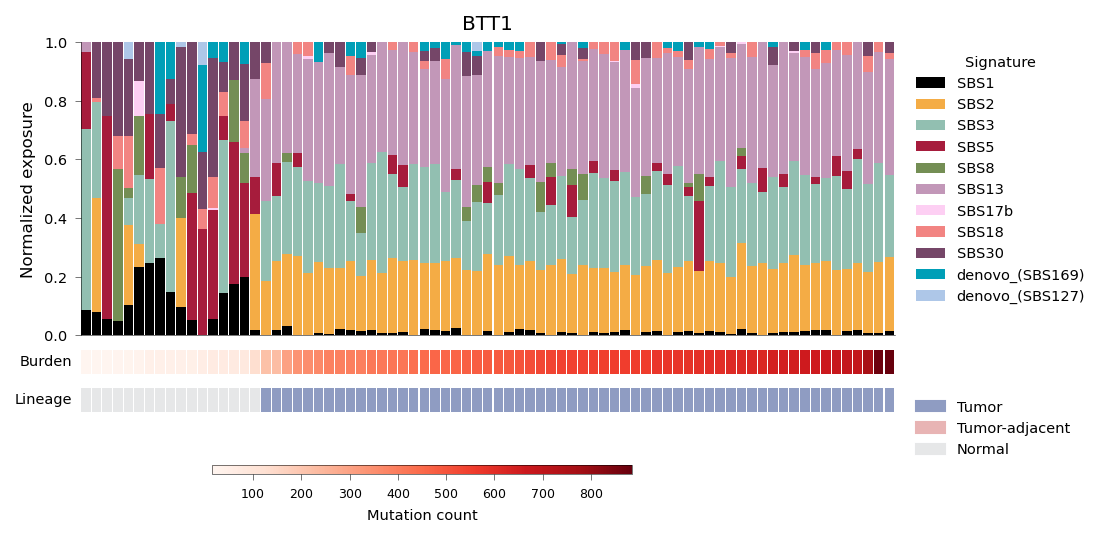

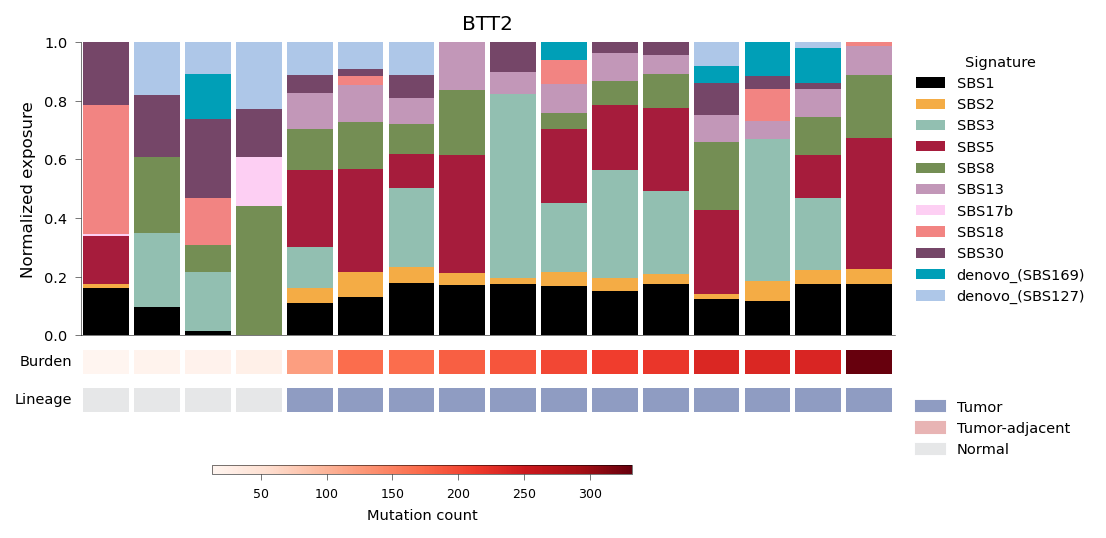

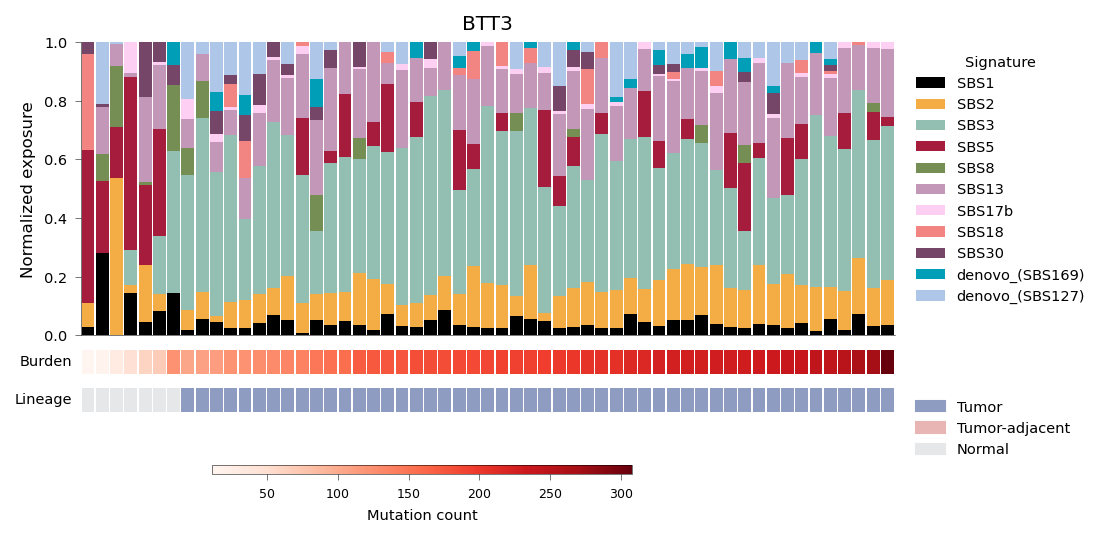

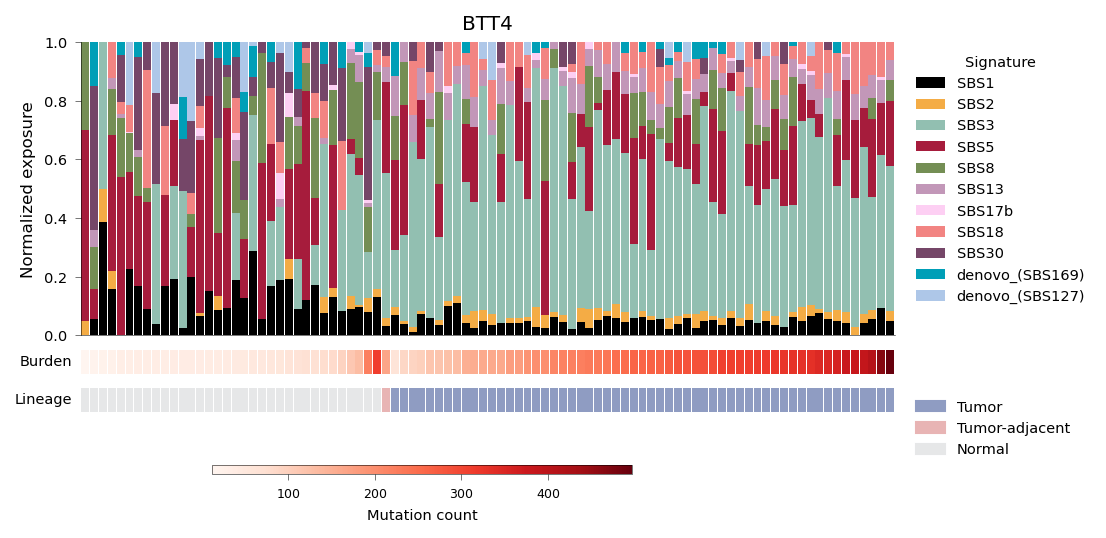

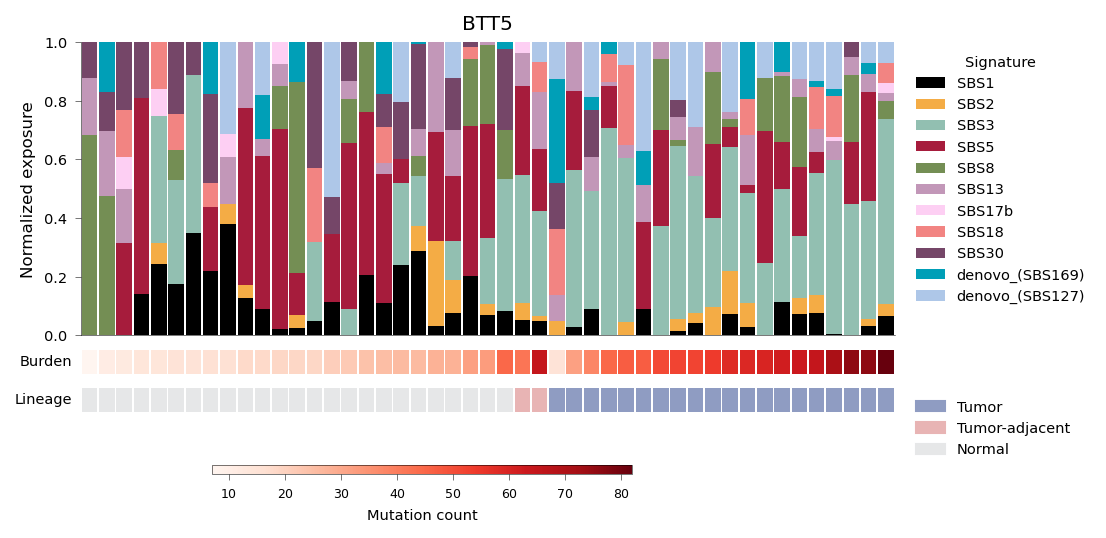

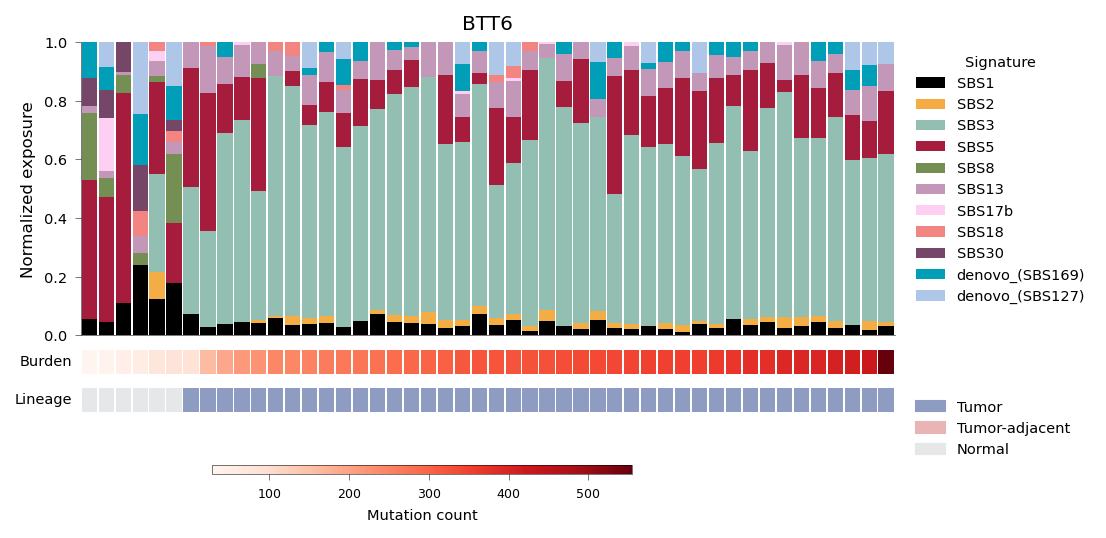

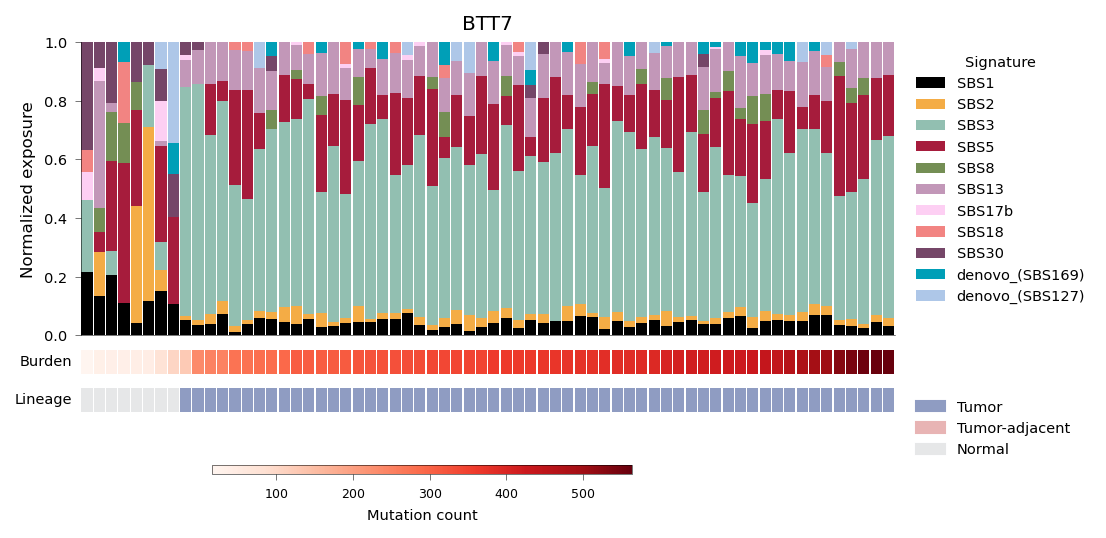

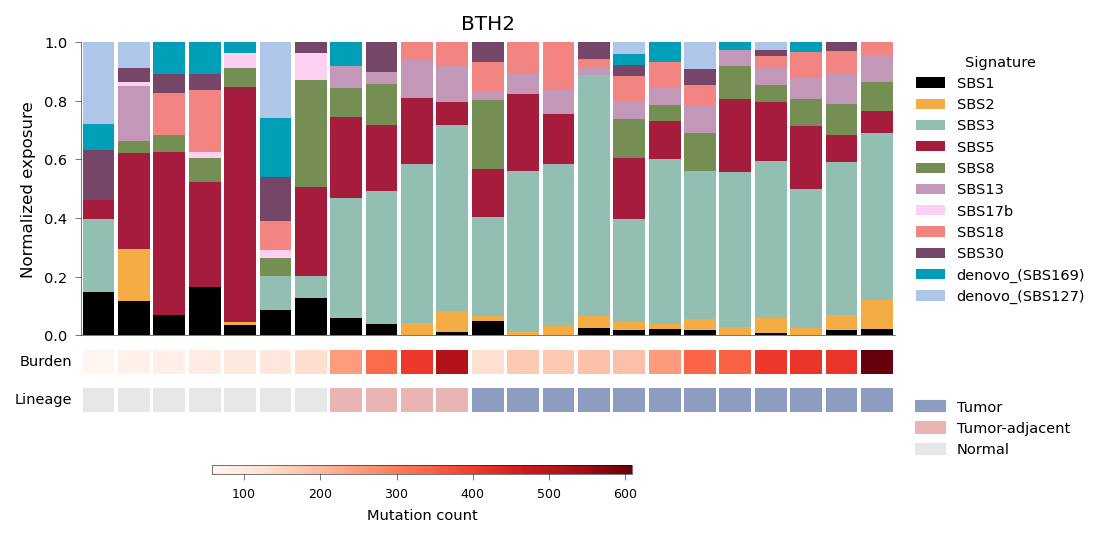

In [3]:
for sample in sample_of.unique():
    idx = sample_of.index[sample_of == sample]
    order = sorted(idx, key=lambda c: (LINEAGE_ORDER[lineage[c]], burden[c]))
    sub, cnt = exposures.loc[order], burden.loc[order].values
    x = np.arange(len(order))
    norm = mcolors.Normalize(vmin=cnt.min(), vmax=cnt.max())

    fig = plt.figure(figsize=(7, 3.2))
    gs = gridspec.GridSpec(3, 1, height_ratios=[6, 0.5, 0.5], hspace=0.12)
    ax1, ax2, ax3 = (plt.subplot(gs[i]) for i in range(3))

    bottom = np.zeros(len(order))
    for sig in SIGNATURES:
        ax1.bar(x, sub[sig].values, bottom=bottom, width=0.9, color=SIG_COLOR[sig], label=sig, linewidth=0)
        bottom += sub[sig].values
    ax1.set(title=sample, ylabel="Normalized exposure", xticks=[])
    ax1.set_xlim(-0.5, len(order)-0.5); ax1.set_ylim(0, 1)
    ax1.legend(title="Signature", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)

    ax2.bar(x, 1, width=0.9, color=[cm.Reds(norm(v)) for v in cnt])
    ax2.set(xlim=(-0.5, len(order)-0.5), xticks=[], yticks=[])
    ax2.set_ylabel("Burden", rotation=0, ha="right", va="center", fontsize=7)
    for s in ax2.spines.values(): s.set_visible(False)

    ax3.bar(x, 1, width=0.9, color=[LINEAGE_STYLE[lineage[c]][0] for c in order])
    ax3.set(xlim=(-0.5, len(order)-0.5), xticks=[], yticks=[])
    ax3.set_ylabel("Lineage", rotation=0, ha="right", va="center", fontsize=7)
    for s in ax3.spines.values(): s.set_visible(False)
    ax3.legend(handles=[Patch(color=c, label=l) for c, l in LINEAGE_STYLE.values()],
               loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=7)

    cax = fig.add_axes([0.25, -0.02, 0.4, 0.02])
    sm = cm.ScalarMappable(cmap=cm.Reds, norm=norm); sm.set_array([])
    cb = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cb.set_label("Mutation count", fontsize=7); cb.ax.tick_params(labelsize=6, width=0.25)

    fig.savefig(f"{OUTDIR}/{sample}_exposures.pdf", bbox_inches="tight")
    plt.show()
